# Matrix Calculus for Machine Learning

### Derivatives · Gradients · Directional Derivatives · Total Derivative · Jacobian · Hessian · Gradient Cookbook

Welcome! This notebook builds **matrix calculus** from the ground up — the language that *every* optimization
algorithm in machine learning secretly speaks. If you can take a derivative, you already have the intuition;
we just need to scale it up from a single number to vectors and matrices.

We will go from `f(x)` (scalar in, scalar out) all the way to `f(W)` (matrix in, scalar out), always asking
the same question:

> **"If I nudge the input a tiny bit, how much does the output change — and in which direction should I nudge to climb fastest?"**

That single question *is* the whole subject.

---

#### 🎯 Why a quant should care

Matrix calculus is one of the **most heavily tested topics in quantitative trading interviews**, because it sits
at the intersection of linear algebra, optimization, and probability. You will be asked to:

- Differentiate a **quadratic form** $\mathbf{x}^\top A \mathbf{x}$ on the spot (this is *the* classic).
- Derive the **normal equations** for least squares by setting a gradient to zero.
- Reason about the **Hessian** to decide if a critical point is a min, max, or saddle (convexity!).
- Take the gradient of a **log-likelihood** or **log-det** term (portfolio optimization, Gaussian models).

Throughout, I'll drop a **🔔 Quant interview alert** whenever we hit something that shows up again and again.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

np.random.seed(0)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

# Our consistent color palette
PALETTE = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy"]
print("Setup complete. NumPy version:", np.__version__)

Setup complete. NumPy version: 2.4.6


## 1 · The Scalar Derivative — our anchor

Before vectors, let's nail the one idea everything else is a generalization of.

For a function $f:\mathbb{R}\to\mathbb{R}$, the derivative at a point $x$ is

$$ f'(x) \;=\; \lim_{h\to 0} \frac{f(x+h) - f(x)}{h}. $$

**What does this *mean*?** Think of $f$ as a machine. You feed in $x$, it spits out $f(x)$.
The derivative answers: *"if I wiggle the input by a tiny amount $h$, the output wiggles by approximately $f'(x)\cdot h$."*

$$ f(x+h) \approx \underbrace{f(x)}_{\text{where you are}} + \underbrace{f'(x)}_{\text{slope}} \cdot \underbrace{h}_{\text{nudge}} $$

So $f'(x)$ is just a **conversion rate**: "for every unit I push the input, the output moves by this much."
The whole point of matrix calculus is keeping this *exact same idea* alive when the input is a vector or a matrix.

> **Key insight:** A derivative is the best **linear approximation** of a function near a point. Everything that
> follows — gradients, Jacobians, Hessians — is just "what does the best linear (or quadratic) approximation look
> like when the input has more than one number?"

Let's see this linear approximation in action.

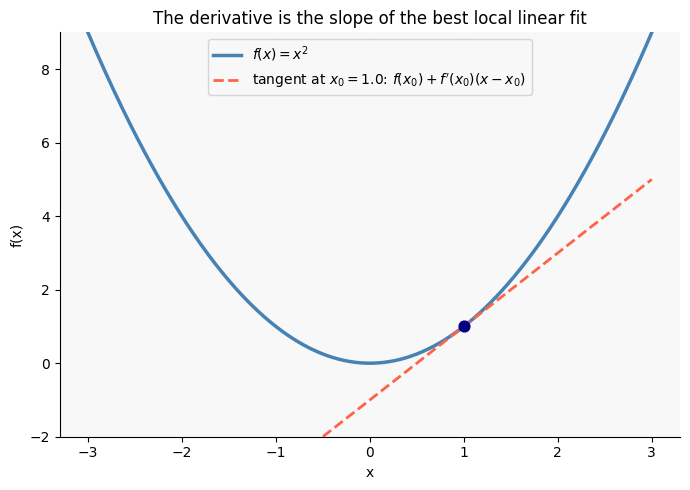

In [2]:
# f(x) = x^2 - we know f'(x) = 2x. Let's SEE the linear approximation.
def f(x):
    return x**2

def fprime(x):
    return 2*x

x = np.linspace(-3, 3, 400)
x0 = 1.0                      # the point where we linearize
tangent = f(x0) + fprime(x0)*(x - x0)   # f(x0) + f'(x0)(x - x0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, f(x), color=PALETTE[0], lw=2.5, label=r"$f(x)=x^2$")
ax.plot(x, tangent, color=PALETTE[1], lw=2, ls="--",
        label=fr"tangent at $x_0={x0}$: $f(x_0)+f'(x_0)(x-x_0)$")
ax.scatter([x0], [f(x0)], color=PALETTE[4], zorder=5, s=60)
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_title("The derivative is the slope of the best local linear fit")
ax.set_ylim(-2, 9)
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2 · From slope to gradient — many inputs

Now let $f:\mathbb{R}^n\to\mathbb{R}$ — **many numbers in, one number out**. This is the shape of almost every
*loss function* in ML: $\mathcal{L}(\mathbf{w})$ takes a whole weight vector and returns a single scalar "badness".

A **partial derivative** $\frac{\partial f}{\partial x_i}$ asks the scalar question one coordinate at a time:
*"freeze every input except $x_i$, then how fast does $f$ change as I wiggle $x_i$?"*

Stack all $n$ partials into a vector and you get the **gradient**:

$$ \nabla f(\mathbf{x}) \;=\; \begin{bmatrix} \dfrac{\partial f}{\partial x_1} \\[6pt] \dfrac{\partial f}{\partial x_2} \\[2pt] \vdots \\[2pt] \dfrac{\partial f}{\partial x_n} \end{bmatrix}. $$

**Notation convention (memorize this):** for a scalar-output function, $\nabla f$ is a **column vector** the same
shape as the input $\mathbf{x}$. This "denominator layout" is the ML default — gradients live in the same space as
the parameters, so the update $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla\mathcal{L}$ type-checks.

| Symbol | Shape | Meaning |
|---|---|---|
| $\mathbf{x}$ | $n\times 1$ | input / parameter vector |
| $f(\mathbf{x})$ | scalar | the output (e.g. loss) |
| $\partial f/\partial x_i$ | scalar | sensitivity to coordinate $i$ |
| $\nabla f(\mathbf{x})$ | $n\times 1$ | the gradient — all sensitivities stacked |

### The two superpowers of the gradient

1. **Direction of steepest ascent.** $\nabla f$ points in the direction in which $f$ increases *fastest*. Its
   negative, $-\nabla f$, points downhill fastest — that's why gradient *descent* works.
2. **Orthogonal to level sets.** The gradient is always perpendicular to the contour lines (curves of constant $f$).
   Intuition: along a contour the height doesn't change, so the "uphill" direction must be at right angles to it.

> **Key insight:** The gradient is not just "the derivative for vectors." It is a **compass**: at every point it
> tells you the single best direction to move to increase the output, and how steep that climb is (its length).

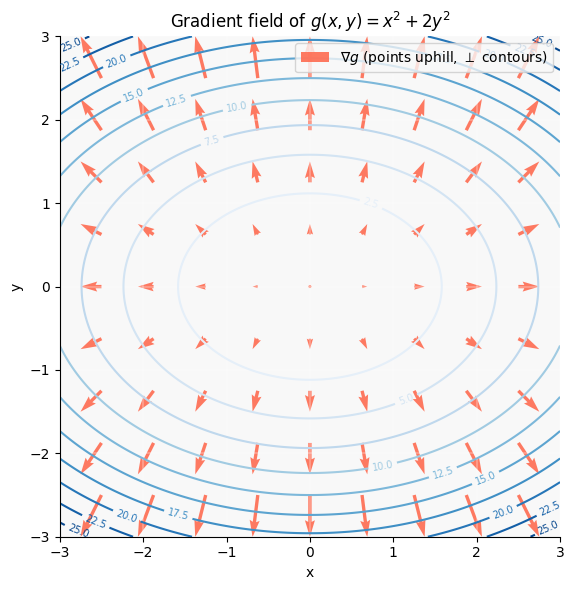

In [3]:
# Visualize a gradient field on a 2D function and confirm:
#   (a) gradients point "uphill", (b) gradients are perpendicular to contours.
def g(x, y):
    return x**2 + 2*y**2          # a tilted bowl

def grad_g(x, y):
    return np.array([2*x, 4*y])   # [df/dx, df/dy]

xs = np.linspace(-3, 3, 300)
ys = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(xs, ys)
Z = g(X, Y)

# sparse grid for arrows
xa = np.linspace(-2.5, 2.5, 9)
ya = np.linspace(-2.5, 2.5, 9)
Xa, Ya = np.meshgrid(xa, ya)
U, V = 2*Xa, 4*Ya               # gradient components

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contour(X, Y, Z, levels=12, cmap="Blues")
ax.clabel(cs, inline=True, fontsize=7)
ax.quiver(Xa, Ya, U, V, color=PALETTE[1], alpha=0.85,
          label=r"$\nabla g$ (points uphill, $\perp$ contours)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"Gradient field of $g(x,y)=x^2+2y^2$")
ax.set_aspect("equal"); ax.legend(loc="upper right")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3 · Directional derivatives — "how fast in *this* direction?"

The gradient bundles together the rate of change along each axis. But what if I want to walk in some arbitrary
direction $\mathbf{u}$ (a unit vector) — not necessarily along an axis? That's the **directional derivative**:

$$ D_{\mathbf{u}} f(\mathbf{x}) \;=\; \lim_{h\to 0}\frac{f(\mathbf{x}+h\mathbf{u}) - f(\mathbf{x})}{h}
   \;=\; \nabla f(\mathbf{x})^\top \mathbf{u}. $$

Read the right-hand side carefully — it's a **dot product** between the gradient and your chosen direction. And a
dot product has a beautiful geometric form:

$$ D_{\mathbf{u}} f = \|\nabla f\|\,\|\mathbf{u}\|\cos\theta = \|\nabla f\|\cos\theta, $$

since $\|\mathbf{u}\|=1$. Here $\theta$ is the angle between your walking direction and the gradient.

**This one formula explains gradient descent geometrically:**

- $\theta = 0$ (walk *with* the gradient): $\cos\theta=1$ → **maximal increase**. The steepest-ascent direction *is* the gradient.
- $\theta = 180^\circ$ (walk *against* it): $\cos\theta=-1$ → **maximal decrease**. That's the descent direction $-\nabla f$.
- $\theta = 90^\circ$ (walk along a contour): $\cos\theta=0$ → **no change**. Confirms gradients $\perp$ contours.

> **🔔 Quant interview alert:** "In what direction does $f$ increase fastest, and why is it the gradient?" is a
> classic. The crisp answer: *maximize $\nabla f^\top \mathbf{u}$ over unit $\mathbf{u}$; by Cauchy–Schwarz the max
> is at $\mathbf{u} = \nabla f / \|\nabla f\|$.* Say "Cauchy–Schwarz" and you've won the point.

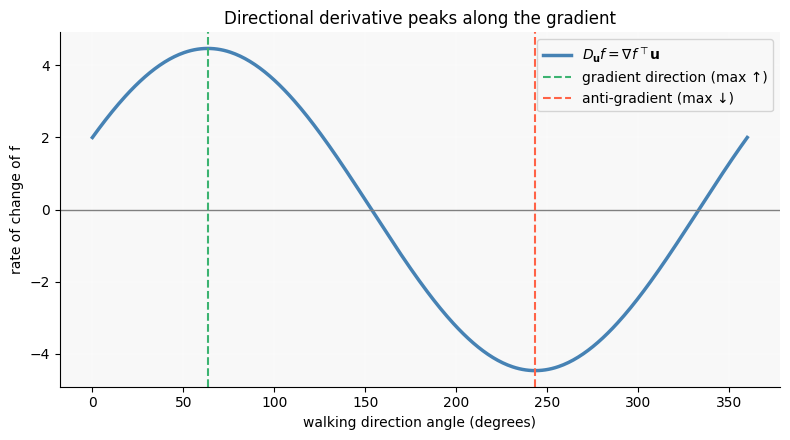

Gradient at [1. 1.]: [2. 4.]
Max directional derivative  = ||grad|| = 4.4721
Confirmed peak of the curve = 4.4721


In [4]:
# Directional derivative as a function of angle, at a fixed point.
pt = np.array([1.0, 1.0])
gvec = grad_g(*pt)                      # gradient at the point

thetas = np.linspace(0, 2*np.pi, 400)
dirs = np.stack([np.cos(thetas), np.sin(thetas)])   # unit vectors
Du = gvec @ dirs                        # directional derivative for each angle

ang_grad = np.arctan2(gvec[1], gvec[0]) # angle of the gradient itself

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.degrees(thetas), Du, color=PALETTE[0], lw=2.5,
        label=r"$D_\mathbf{u}f=\nabla f^\top \mathbf{u}$")
ax.axhline(0, color="grey", lw=1)
ax.axvline(np.degrees(ang_grad), color=PALETTE[2], ls="--",
           label="gradient direction (max ↑)")
ax.axvline(np.degrees(ang_grad+np.pi), color=PALETTE[1], ls="--",
           label="anti-gradient (max ↓)")
ax.set_xlabel("walking direction angle (degrees)")
ax.set_ylabel("rate of change of f")
ax.set_title("Directional derivative peaks along the gradient")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"Gradient at {pt}: {gvec}")
print(f"Max directional derivative  = ||grad|| = {np.linalg.norm(gvec):.4f}")
print(f"Confirmed peak of the curve = {Du.max():.4f}")

## 4 · The total derivative (the differential)

Partial derivatives change one variable at a time. The **total derivative** answers: *what if everything moves at
once?* This is the rigorous version of the "best linear approximation" idea for multiple inputs.

For $f:\mathbb{R}^n\to\mathbb{R}$, the first-order Taylor expansion is

$$ f(\mathbf{x} + \Delta\mathbf{x}) \;\approx\; f(\mathbf{x}) \;+\; \underbrace{\nabla f(\mathbf{x})^\top \Delta\mathbf{x}}_{\text{total change } df}. $$

The term $df = \nabla f^\top d\mathbf{x} = \sum_i \frac{\partial f}{\partial x_i}\, dx_i$ is the **differential**:
each coordinate contributes its own (partial slope) × (its nudge), and you add them all up. It's literally a
weighted sum of nudges, weighted by sensitivities.

**Why this matters practically — the differential is a *computational trick*.** Instead of grinding out partial
derivatives one by one, you manipulate $d(\cdot)$ like algebra and then *read off* the gradient. The rules look
exactly like scalar calculus:

$$ d(\mathbf{a}^\top\mathbf{x}) = \mathbf{a}^\top d\mathbf{x}, \qquad
   d(\mathbf{x}^\top A\mathbf{x}) = d\mathbf{x}^\top A\mathbf{x} + \mathbf{x}^\top A\, d\mathbf{x}
   = \mathbf{x}^\top(A + A^\top)\,d\mathbf{x}. $$

Then you use the **identification rule**: if you can massage the differential into the form $df = \mathbf{g}^\top d\mathbf{x}$,
then $\boxed{\nabla f = \mathbf{g}}$. We'll use this in Section 8 to crank out the whole gradient cookbook.

> **Key insight:** The differential is the bridge between "calculus you know" and "matrix calculus." Treat $dx$ as a
> tiny vector, push it through the algebra, and whatever multiplies it (after transposing to a column) is the gradient.

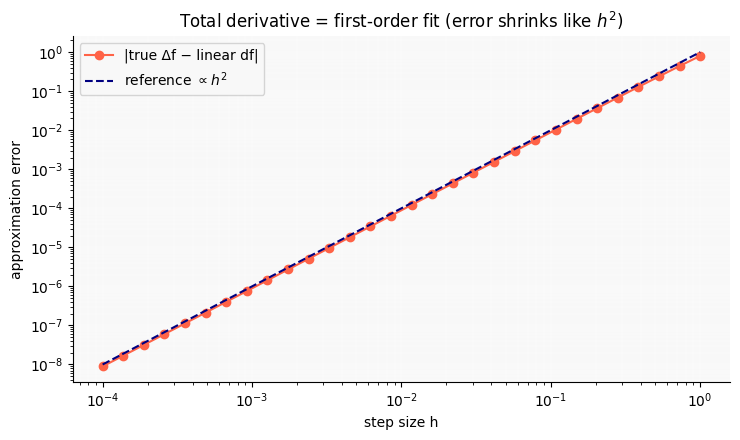

Error scales as h^2 -> the linear term captures all the O(h) change. ✓


In [5]:
# Demonstrate: first-order Taylor approximation accuracy vs step size.
def f3(v):                      # f(x,y) = sin(x) + x*y^2
    x, y = v
    return np.sin(x) + x*y**2

def grad_f3(v):
    x, y = v
    return np.array([np.cos(x) + y**2, 2*x*y])

x0 = np.array([0.5, 1.0])
g0 = grad_f3(x0)
direction = np.array([1.0, -0.5]); direction /= np.linalg.norm(direction)

steps = np.logspace(-4, 0, 30)
true_change, lin_change = [], []
for h in steps:
    dx = h*direction
    true_change.append(f3(x0+dx) - f3(x0))      # actual Delta f
    lin_change.append(g0 @ dx)                   # df = grad^T dx

true_change = np.array(true_change); lin_change = np.array(lin_change)
err = np.abs(true_change - lin_change)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(steps, err, "o-", color=PALETTE[1], label="|true Δf − linear df|")
ax.loglog(steps, steps**2, "--", color=PALETTE[4], label=r"reference $\propto h^2$")
ax.set_xlabel("step size h"); ax.set_ylabel("approximation error")
ax.set_title("Total derivative = first-order fit (error shrinks like $h^2$)")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
print("Error scales as h^2 -> the linear term captures all the O(h) change. ✓")

## 5 · The Jacobian — vector in, vector out

So far the output was a single scalar. Now let $\mathbf{f}:\mathbb{R}^n\to\mathbb{R}^m$ — **many in, many out**.
Think of a neural-network layer $\mathbf{f}(\mathbf{x}) = \sigma(W\mathbf{x})$, or a coordinate transformation.

We now have $m$ outputs, each with $n$ partial derivatives. Arrange them in a matrix — the **Jacobian**:

$$ J(\mathbf{x}) \;=\; \frac{\partial \mathbf{f}}{\partial \mathbf{x}} \;=\;
\begin{bmatrix}
\dfrac{\partial f_1}{\partial x_1} & \cdots & \dfrac{\partial f_1}{\partial x_n}\\
\vdots & \ddots & \vdots\\
\dfrac{\partial f_m}{\partial x_1} & \cdots & \dfrac{\partial f_m}{\partial x_n}
\end{bmatrix} \in \mathbb{R}^{m\times n}. $$

**How to read it:** *row $i$ is the gradient of output $f_i$*; *column $j$ is "how every output responds to input $x_j$."*
The whole matrix is the best linear map approximating $\mathbf{f}$ near $\mathbf{x}$:

$$ \mathbf{f}(\mathbf{x}+\Delta\mathbf{x}) \approx \mathbf{f}(\mathbf{x}) + J(\mathbf{x})\,\Delta\mathbf{x}. $$

Compare with the scalar case $f(x+h)\approx f(x)+f'(x)h$: the scalar slope $f'(x)$ has been **promoted to a matrix**.

Two special cases tie everything together:
- If $m=1$ (scalar output), the Jacobian is a single row — it's the **transpose of the gradient**, $J = \nabla f^\top$.
- The **chain rule** becomes matrix multiplication: $J_{\mathbf{f}\circ\mathbf{g}} = J_{\mathbf{f}}\,J_{\mathbf{g}}$.
  *This is exactly what backpropagation computes* — a product of Jacobians, right to left.

> **🔔 Quant interview alert:** The **determinant of the Jacobian** is the local volume-scaling factor of a
> transformation — it's the $|{\det J}|$ in the change-of-variables formula for probability densities. If you
> transform a random variable $Y = g(X)$, the density picks up a factor $1/|\det J_g|$. Common in option-pricing
> change-of-measure and copula questions.

In [6]:
# Polar -> Cartesian map: f(r, theta) = (r cos theta, r sin theta)
# Known Jacobian: [[cos t, -r sin t],[sin t, r cos t]], det = r.
def polar_to_cart(v):
    r, t = v
    return np.array([r*np.cos(t), r*np.sin(t)])

def jacobian_analytic(v):
    r, t = v
    return np.array([[np.cos(t), -r*np.sin(t)],
                     [np.sin(t),  r*np.cos(t)]])

def jacobian_numeric(func, v, eps=1e-6):
    v = np.asarray(v, float)
    f0 = func(v); m = len(f0); n = len(v)
    J = np.zeros((m, n))
    for j in range(n):
        dv = np.zeros(n); dv[j] = eps
        J[:, j] = (func(v+dv) - func(v-dv)) / (2*eps)   # central difference
    return J

pt = np.array([2.0, np.pi/4])
Ja, Jn = jacobian_analytic(pt), jacobian_numeric(polar_to_cart, pt)
print("Analytic Jacobian:\n", np.round(Ja, 6))
print("\nNumeric  Jacobian:\n", np.round(Jn, 6))
print(f"\nMax abs difference: {np.abs(Ja-Jn).max():.2e}  (analytic == numeric ✓)")
print(f"det(J) = {np.linalg.det(Ja):.4f}  ==  r = {pt[0]}  (volume scaling factor)")

Analytic Jacobian:
 [[ 0.707107 -1.414214]
 [ 0.707107  1.414214]]

Numeric  Jacobian:
 [[ 0.707107 -1.414214]
 [ 0.707107  1.414214]]

Max abs difference: 5.26e-11  (analytic == numeric ✓)
det(J) = 2.0000  ==  r = 2.0  (volume scaling factor)


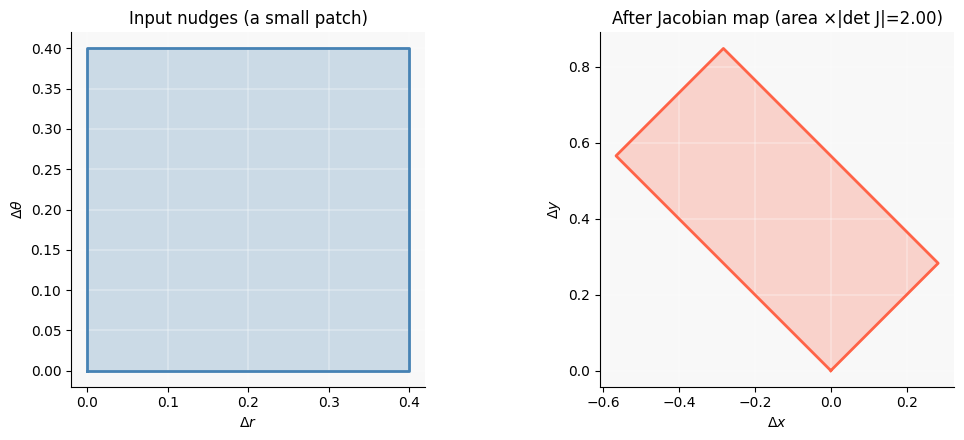

In [7]:
# Visualize the Jacobian as a LOCAL LINEAR MAP: a tiny square gets sheared/scaled.
pt = np.array([2.0, np.pi/4])
J = jacobian_analytic(pt)
square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T * 0.4   # unit-ish square
mapped = (J @ square)                                        # apply linear map

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(square[0], square[1], color=PALETTE[0], lw=2)
axes[0].fill(square[0], square[1], color=PALETTE[0], alpha=0.25)
axes[0].set_title("Input nudges (a small patch)")
axes[0].set_xlabel(r"$\Delta r$"); axes[0].set_ylabel(r"$\Delta\theta$")
axes[0].set_aspect("equal"); axes[0].grid(alpha=0.3)

axes[1].plot(mapped[0], mapped[1], color=PALETTE[1], lw=2)
axes[1].fill(mapped[0], mapped[1], color=PALETTE[1], alpha=0.25)
axes[1].set_title(f"After Jacobian map (area ×|det J|={abs(np.linalg.det(J)):.2f})")
axes[1].set_xlabel(r"$\Delta x$"); axes[1].set_ylabel(r"$\Delta y$")
axes[1].set_aspect("equal"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6 · The Hessian — curvature, and the second derivative for vectors

The gradient tells you the slope. But slope alone can't distinguish a valley bottom from a hilltop from a saddle —
they all have $\nabla f = \mathbf{0}$! To classify them we need **curvature**, i.e. the *second* derivative.

For $f:\mathbb{R}^n\to\mathbb{R}$, the **Hessian** is the matrix of all second partial derivatives:

$$ H(\mathbf{x}) = \nabla^2 f(\mathbf{x}) =
\begin{bmatrix}
\dfrac{\partial^2 f}{\partial x_1^2} & \cdots & \dfrac{\partial^2 f}{\partial x_1\partial x_n}\\
\vdots & \ddots & \vdots\\
\dfrac{\partial^2 f}{\partial x_n\partial x_1} & \cdots & \dfrac{\partial^2 f}{\partial x_n^2}
\end{bmatrix} \in \mathbb{R}^{n\times n}. $$

Note: the Hessian is exactly the **Jacobian of the gradient** ($H = J_{\nabla f}$). And by Clairaut's theorem
(mixed partials commute for smooth $f$), **$H$ is symmetric**.

The second-order Taylor expansion shows what it's for:

$$ f(\mathbf{x}+\Delta\mathbf{x}) \approx f(\mathbf{x}) + \nabla f^\top \Delta\mathbf{x}
   + \tfrac{1}{2}\,\Delta\mathbf{x}^\top H\, \Delta\mathbf{x}. $$

That last term is a **quadratic form** in the Hessian — it's the "bowl" (or "dome", or "saddle") that locally
approximates the surface. The sign of $\Delta\mathbf{x}^\top H\, \Delta\mathbf{x}$ tells you which way the surface bends.

### The second-derivative test (this is the payoff)

At a critical point ($\nabla f = 0$), look at the **eigenvalues** of $H$:

| Hessian property | Eigenvalues | Critical point is a... |
|---|---|---|
| Positive definite | all $> 0$ | **local minimum** (bowl up) |
| Negative definite | all $< 0$ | **local maximum** (dome) |
| Indefinite | mixed signs | **saddle point** |
| Positive semidefinite | all $\ge 0$, some $=0$ | flat direction (inconclusive) |

> **🔔 Quant interview alert:** This is *the* convexity question. **A twice-differentiable function is convex iff its
> Hessian is positive semidefinite everywhere.** Convex ⟹ any local min is global ⟹ optimization is "easy." Expect to
> be asked *is this loss convex?* — the answer is *compute the Hessian and check its eigenvalues / PSD-ness*.

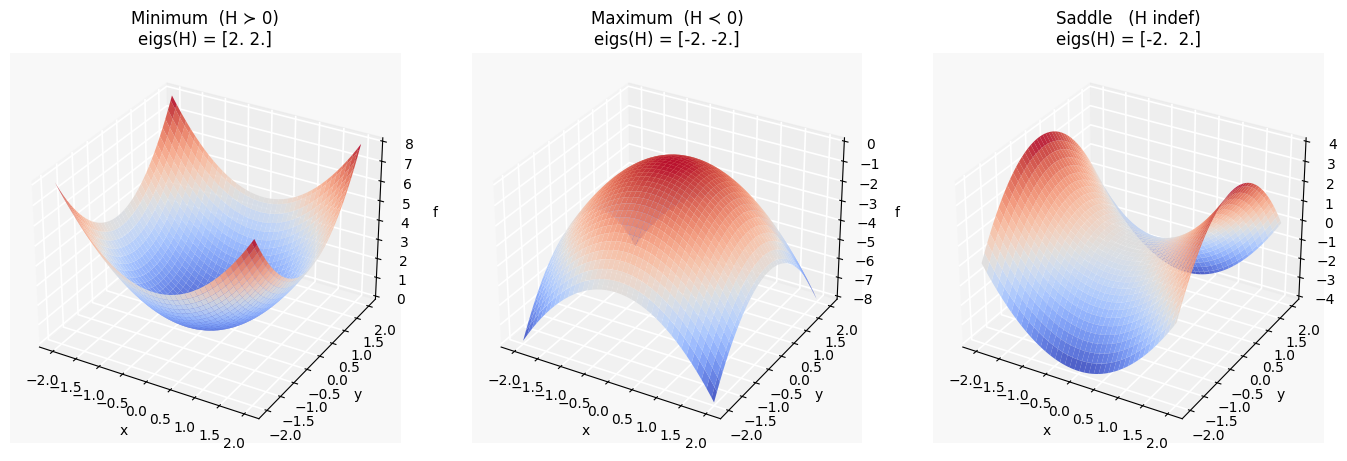

Same gradient (0) at the origin in all three — only the Hessian tells them apart.


In [8]:
# Three canonical 2D surfaces: min, max, saddle - classified by the Hessian.
surfaces = {
    "Minimum  (H ≻ 0)":  (lambda X, Y:  X**2 + Y**2,   np.array([[2,0],[0,2]])),
    "Maximum  (H ≺ 0)":  (lambda X, Y: -(X**2 + Y**2), np.array([[-2,0],[0,-2]])),
    "Saddle   (H indef)":(lambda X, Y:  X**2 - Y**2,   np.array([[2,0],[0,-2]])),
}
xs = ys = np.linspace(-2, 2, 80)
X, Y = np.meshgrid(xs, ys)

fig = plt.figure(figsize=(14, 4.5))
for k, (name, (func, H)) in enumerate(surfaces.items(), 1):
    ax = fig.add_subplot(1, 3, k, projection="3d")
    ax.plot_surface(X, Y, func(X, Y), cmap="coolwarm", alpha=0.9,
                    linewidth=0, antialiased=True)
    eig = np.linalg.eigvalsh(H)
    ax.set_title(f"{name}\neigs(H) = {eig}")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f")
plt.tight_layout(); plt.show()

print("Same gradient (0) at the origin in all three — only the Hessian tells them apart.")

## 7 · The gradient cookbook — derivatives you must know cold

These are the building blocks. In an interview you should be able to produce each gradient *and* sketch the
derivation via the differential trick from Section 4. We use **denominator layout** so every gradient has the
same shape as the variable.

Let $\mathbf{a}\in\mathbb{R}^n$ be a constant vector, $A\in\mathbb{R}^{n\times n}$ a constant matrix, $\mathbf{x}\in\mathbb{R}^n$.

| # | Function $f(\mathbf{x})$ | Gradient $\nabla_\mathbf{x} f$ | One-line reason |
|---|---|---|---|
| 1 | $\mathbf{a}^\top\mathbf{x} = \mathbf{x}^\top\mathbf{a}$ | $\mathbf{a}$ | $df=\mathbf{a}^\top d\mathbf{x}$ |
| 2 | $\mathbf{x}^\top A\,\mathbf{x}$ (quadratic form) | $(A+A^\top)\mathbf{x}$ | product rule on the differential |
| 2b| $\mathbf{x}^\top A\,\mathbf{x}$, $A$ symmetric | $2A\mathbf{x}$ | since $A=A^\top$ |
| 3 | $\|\mathbf{x}\|_2^2 = \mathbf{x}^\top\mathbf{x}$ | $2\mathbf{x}$ | special case of #2b with $A=I$ |
| 4 | $\|\mathbf{x}\|_2 = \sqrt{\mathbf{x}^\top\mathbf{x}}$ | $\mathbf{x}/\|\mathbf{x}\|_2$ | chain rule; the **unit vector** |
| 5 | $\|A\mathbf{x}-\mathbf{b}\|_2^2$ (least squares) | $2A^\top(A\mathbf{x}-\mathbf{b})$ | chain rule + #3 |

And two matrix-input gems ($X\in\mathbb{R}^{n\times n}$, scalar output):

| # | Function $f(X)$ | Gradient $\nabla_X f$ | Note |
|---|---|---|---|
| 6 | $\log\det X$ | $X^{-\top} = (X^{-1})^\top$ | symmetric $X$: $X^{-1}$ |
| 7 | $\operatorname{tr}(A^\top X)$ | $A$ | the "inner product" of matrices |

### Derivation of the star of the show: $\nabla(\mathbf{x}^\top A\mathbf{x})$

Use the differential. Let $f = \mathbf{x}^\top A \mathbf{x}$. Nudge $\mathbf{x}\to\mathbf{x}+d\mathbf{x}$ and keep first-order terms:

$$ df = (d\mathbf{x})^\top A\mathbf{x} + \mathbf{x}^\top A\,(d\mathbf{x}). $$

Both terms are scalars, and a scalar equals its own transpose, so $(d\mathbf{x})^\top A\mathbf{x} = \mathbf{x}^\top A^\top d\mathbf{x}$. Hence

$$ df = \mathbf{x}^\top A^\top d\mathbf{x} + \mathbf{x}^\top A\, d\mathbf{x} = \mathbf{x}^\top (A^\top + A)\, d\mathbf{x}. $$

Identify $df = \mathbf{g}^\top d\mathbf{x}$ to read off $\mathbf{g} = (A+A^\top)\mathbf{x}$.  If $A$ is symmetric this collapses to the famous $\boxed{2A\mathbf{x}}$ — the matrix analogue of $\frac{d}{dx}(ax^2)=2ax$.

> **🔔 Quant interview alert:** The triple "$\nabla(\mathbf{a}^\top\mathbf{x})=\mathbf{a}$, $\nabla(\mathbf{x}^\top A\mathbf{x})=(A+A^\top)\mathbf{x}$, and $\nabla\|A\mathbf{x}-\mathbf{b}\|^2 = 2A^\top(A\mathbf{x}-\mathbf{b})$" is asked *constantly*. Setting #5 to zero gives the **normal equations** $A^\top A\mathbf{x}=A^\top\mathbf{b}$ — be ready to derive linear regression's closed form on the whiteboard.

In [9]:
# Numerically verify the cookbook with a general finite-difference gradient checker.
def numeric_grad(func, x, eps=1e-6):
    x = np.asarray(x, float); grad = np.zeros_like(x)
    for i in range(x.size):
        dx = np.zeros_like(x); dx.flat[i] = eps
        grad.flat[i] = (func(x+dx) - func(x-dx)) / (2*eps)
    return grad

n = 4
a = np.random.randn(n)
A = np.random.randn(n, n)
S = A + A.T                       # a symmetric matrix
b = np.random.randn(n)
x = np.random.randn(n)

checks = [
    ("a^T x",                 lambda v: a @ v,                          lambda v: a),
    ("x^T A x  (general)",    lambda v: v @ A @ v,                     lambda v: (A + A.T) @ v),
    ("x^T S x  (symmetric)",  lambda v: v @ S @ v,                     lambda v: 2 * S @ v),
    ("||x||^2",               lambda v: v @ v,                         lambda v: 2 * v),
    ("||x||_2",               lambda v: np.sqrt(v @ v),                lambda v: v / np.sqrt(v @ v)),
    ("||Ax - b||^2",          lambda v: (A@v - b) @ (A@v - b),         lambda v: 2 * A.T @ (A@v - b)),
]

print(f"{'function':24s}{'max |analytic - numeric|':>26s}")
print("-" * 50)
for name, fn, gn in checks:
    err = np.abs(gn(x) - numeric_grad(fn, x)).max()
    print(f"{name:24s}{err:>26.2e}")
print("\nAll ~1e-7  ->  the cookbook gradients are correct. ✓")

function                  max |analytic - numeric|
--------------------------------------------------
a^T x                                     4.53e-10
x^T A x  (general)                        1.15e-09
x^T S x  (symmetric)                      4.08e-09
||x||^2                                   5.27e-10
||x||_2                                   1.54e-10
||Ax - b||^2                              1.36e-08

All ~1e-7  ->  the cookbook gradients are correct. ✓


In [10]:
# Matrix-input gradients: log det and trace.
M = np.random.randn(5, 5)
Xsym = M @ M.T + 5*np.eye(5)       # symmetric positive-definite -> log det well-defined

def numeric_grad_mat(func, Xm, eps=1e-6):
    Xm = np.asarray(Xm, float); G = np.zeros_like(Xm)
    it = np.nditer(Xm, flags=["multi_index"])
    for _ in it:
        i = it.multi_index
        dX = np.zeros_like(Xm); dX[i] = eps
        G[i] = (func(Xm+dX) - func(Xm-dX)) / (2*eps)
    return G

# grad log det X = X^{-T}; for symmetric X this is X^{-1}
g_logdet_num = numeric_grad_mat(lambda Xm: np.log(np.linalg.det(Xm)), Xsym)
g_logdet_ana = np.linalg.inv(Xsym).T
print("log det  -> max error:", f"{np.abs(g_logdet_num - g_logdet_ana).max():.2e}")

# grad tr(A^T X) = A
Aconst = np.random.randn(5, 5)
g_tr_num = numeric_grad_mat(lambda Xm: np.trace(Aconst.T @ Xm), Xsym)
print("tr(A^T X)-> max error:", f"{np.abs(g_tr_num - Aconst).max():.2e}")
print("\nMatrix-calculus identities confirmed numerically. ✓")

log det  -> max error: 9.41e-10
tr(A^T X)-> max error: 1.61e-09

Matrix-calculus identities confirmed numerically. ✓


## 8 · Putting it together — least squares by gradient descent (from scratch)

Time to use *all* of it. We'll fit a linear model $\hat{\mathbf{y}} = X\mathbf{w}$ by minimizing the squared-error loss

$$ \mathcal{L}(\mathbf{w}) = \tfrac{1}{N}\,\|X\mathbf{w} - \mathbf{y}\|_2^2. $$

**Gradient (cookbook #5, scaled by $1/N$):**

$$ \nabla_\mathbf{w}\mathcal{L} = \tfrac{2}{N}\,X^\top (X\mathbf{w} - \mathbf{y}). $$

**Hessian:** $\nabla^2_\mathbf{w}\mathcal{L} = \tfrac{2}{N} X^\top X$, which is positive semidefinite — so the loss is
**convex**, gradient descent converges to the global min, and that min satisfies the **normal equations**
$X^\top X\,\mathbf{w} = X^\top \mathbf{y}$ (set the gradient to zero). Watch our from-scratch descent march toward
exactly that closed-form solution.

The update rule is just "step downhill":  $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla_\mathbf{w}\mathcal{L}$.

In [11]:
# ---- Dataset: a noisy linear relationship with a bias term ----
N = 200
x_feat = np.linspace(-3, 3, N)
true_w, true_b = 2.5, -1.0
y = true_w * x_feat + true_b + np.random.randn(N) * 1.5

X = np.column_stack([x_feat, np.ones(N)])   # design matrix [feature, 1] -> weights [w, b]
print("Design matrix shape:", X.shape, " (column of 1s folds in the bias)")

Design matrix shape: (200, 2)  (column of 1s folds in the bias)


In [12]:
# ---- Gradient descent from scratch ----
def loss(w):
    r = X @ w - y
    return (r @ r) / N

def grad_loss(w):
    return (2 / N) * X.T @ (X @ w - y)          # cookbook #5, scaled

w = np.zeros(2)
eta = 0.05
n_iter = 200
loss_history = []
w_history = [w.copy()]

for _ in range(n_iter):
    loss_history.append(loss(w))
    w = w - eta * grad_loss(w)
    w_history.append(w.copy())

w_history = np.array(w_history)

# Closed-form (normal equations) for comparison
w_closed = np.linalg.solve(X.T @ X, X.T @ y)

print(f"Gradient descent   : w = {w[0]:.4f},  b = {w[1]:.4f}")
print(f"Normal equations   : w = {w_closed[0]:.4f},  b = {w_closed[1]:.4f}")
print(f"True parameters    : w = {true_w},  b = {true_b}")
print(f"Final loss         : {loss_history[-1]:.4f}")

Gradient descent   : w = 2.3260,  b = -0.9714
Normal equations   : w = 2.3260,  b = -0.9714
True parameters    : w = 2.5,  b = -1.0
Final loss         : 2.0812


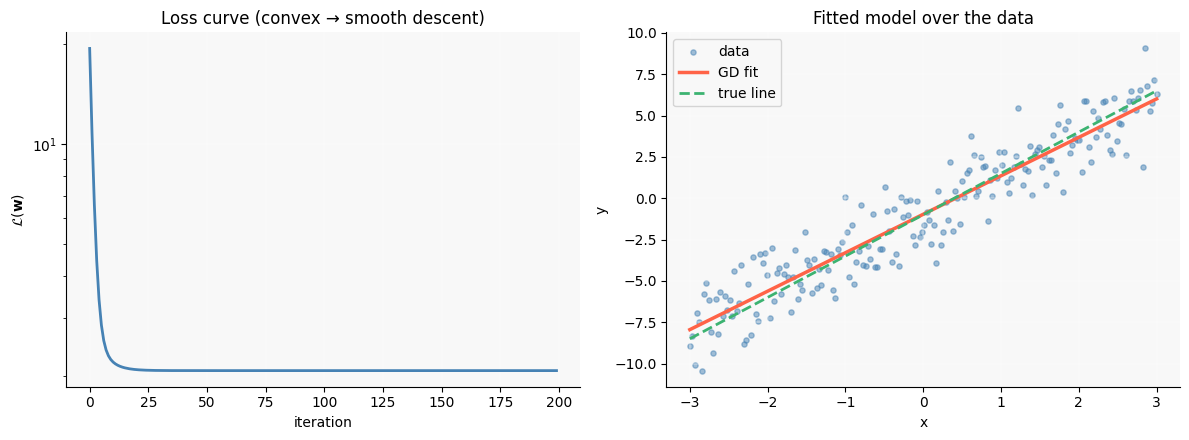

In [13]:
# ---- Loss curve + fitted line ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(loss_history, color=PALETTE[0], lw=2)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$\mathcal{L}(\mathbf{w})$")
axes[0].set_title("Loss curve (convex → smooth descent)")
axes[0].set_yscale("log"); axes[0].grid(alpha=0.3)

axes[1].scatter(x_feat, y, s=14, color=PALETTE[0], alpha=0.5, label="data")
xx = np.array([x_feat.min(), x_feat.max()])
axes[1].plot(xx, w[0]*xx + w[1], color=PALETTE[1], lw=2.5, label="GD fit")
axes[1].plot(xx, true_w*xx + true_b, color=PALETTE[2], lw=2, ls="--", label="true line")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Fitted model over the data")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

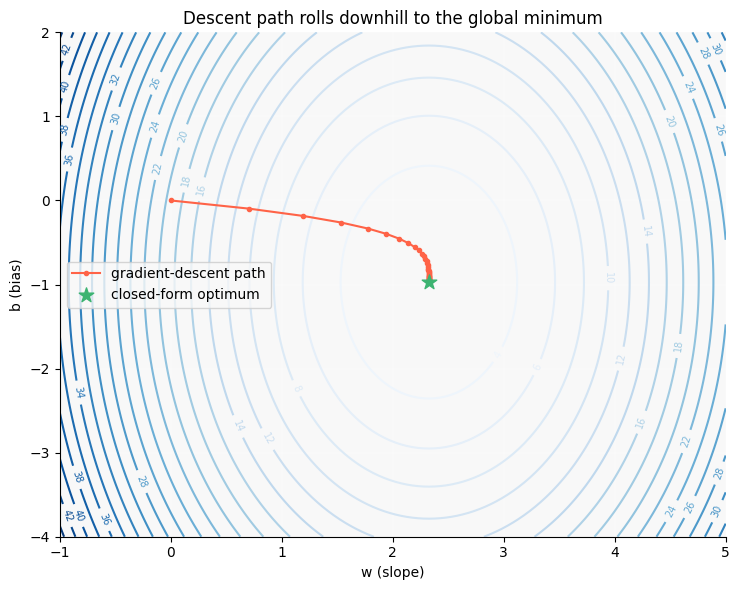

In [14]:
# ---- The descent PATH on the loss landscape (contours = the quadratic bowl) ----
w0s = np.linspace(-1, 5, 120)
w1s = np.linspace(-4, 2, 120)
W0, W1 = np.meshgrid(w0s, w1s)
L = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        L[i, j] = loss(np.array([W0[i, j], W1[i, j]]))

fig, ax = plt.subplots(figsize=(7.5, 6))
cs = ax.contour(W0, W1, L, levels=25, cmap="Blues")
ax.clabel(cs, inline=True, fontsize=7)
ax.plot(w_history[:, 0], w_history[:, 1], "-o", color=PALETTE[1],
        ms=3, lw=1.5, label="gradient-descent path")
ax.scatter([w_closed[0]], [w_closed[1]], color=PALETTE[2], s=120,
           marker="*", zorder=5, label="closed-form optimum")
ax.set_xlabel("w (slope)"); ax.set_ylabel("b (bias)")
ax.set_title("Descent path rolls downhill to the global minimum")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9 · Effect of the learning rate (and an interactive widget)

The learning rate $\eta$ trades **speed against stability**. The Hessian sets the limit: for a quadratic loss with
Hessian $H$, gradient descent converges iff $\eta < 2/\lambda_{\max}(H)$, where $\lambda_{\max}$ is the largest
eigenvalue. Too small → crawls; too big → overshoots and *diverges*.

> **🔔 Quant interview alert:** "Why does gradient descent diverge if the step size is too large?" → because each
> step over-corrects along the steepest (largest-eigenvalue) direction; the convergence bound $\eta < 2/\lambda_{\max}$
> falls straight out of the eigen-decomposition of the quadratic. **The Hessian's condition number $\lambda_{\max}/\lambda_{\min}$
> controls how fast (or painfully slowly, in a stretched valley) GD converges.**

Stability limit: eta < 2/lambda_max = 0.3300


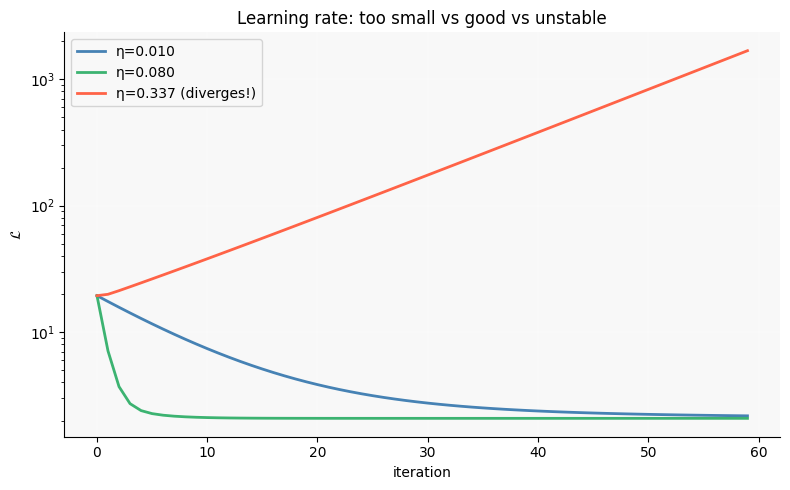

In [15]:
# Side-by-side: too small, just right, too large.
def run_gd(eta, n_iter=60):
    w = np.zeros(2); hist = []
    for _ in range(n_iter):
        hist.append(loss(w)); w = w - eta * grad_loss(w)
    return hist

H = (2/N) * X.T @ X
eta_max = 2 / np.linalg.eigvalsh(H).max()
print(f"Stability limit: eta < 2/lambda_max = {eta_max:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
for eta_try, col in zip([0.01, 0.08, eta_max*1.02], [PALETTE[0], PALETTE[2], PALETTE[1]]):
    label = f"η={eta_try:.3f}"
    if eta_try > eta_max: label += " (diverges!)"
    ax.plot(run_gd(eta_try), color=col, lw=2, label=label)
ax.set_xlabel("iteration"); ax.set_ylabel(r"$\mathcal{L}$")
ax.set_yscale("log"); ax.set_title("Learning rate: too small vs good vs unstable")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [16]:
# Interactive slider for the learning rate (falls back to a static plot if no ipywidgets).
def plot_for_eta(eta=0.05):
    hist = run_gd(eta, n_iter=80)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(hist, color=PALETTE[0], lw=2)
    ax.set_xlabel("iteration"); ax.set_ylabel(r"$\mathcal{L}$")
    ax.set_title(f"Loss for η = {eta:.3f}  (stability limit ≈ {eta_max:.3f})")
    ax.set_yscale("log"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(plot_for_eta,
             eta=FloatSlider(min=0.005, max=float(eta_max*1.1),
                             step=0.005, value=0.05, description="η"))
except Exception as e:
    print("ipywidgets unavailable, showing a static example:", e)
    plot_for_eta(0.05)

interactive(children=(FloatSlider(value=0.05, description='η', max=0.36301824212271977, min=0.005, step=0.005)…

## 10 · Summary

You now have the full toolkit. Every object in this notebook answers the same question — "how does the output respond
to a nudge in the input?" — at a different level of structure:

| Concept | Key Idea |
|---|---|
| **Derivative** $f'(x)$ | Slope = best local *linear* fit; $f(x+h)\approx f(x)+f'(x)h$. |
| **Gradient** $\nabla f$ | Stack of partials; a **compass** pointing in the direction of steepest ascent, $\perp$ to contours. Column vector, same shape as input. |
| **Directional derivative** $\nabla f^\top\mathbf{u}$ | Rate of change along $\mathbf{u}$; max along the gradient (Cauchy–Schwarz). |
| **Total derivative / differential** $df=\nabla f^\top d\mathbf{x}$ | First-order Taylor term; an algebraic *trick* to read off gradients. |
| **Jacobian** $J\in\mathbb{R}^{m\times n}$ | Slope promoted to a matrix for vector→vector maps; chain rule = matrix product (backprop). $|\det J|$ = local volume scaling. |
| **Hessian** $H=\nabla^2 f$ | Symmetric matrix of curvature; eigenvalue signs classify min/max/saddle; **PSD everywhere ⟺ convex**. |
| **$\nabla(\mathbf{a}^\top\mathbf{x})$** | $=\mathbf{a}$. |
| **$\nabla(\mathbf{x}^\top A\mathbf{x})$** | $=(A+A^\top)\mathbf{x}$; $=2A\mathbf{x}$ if symmetric. ⭐ most-tested. |
| **$\nabla\|\mathbf{x}\|_2^2$ / $\nabla\|\mathbf{x}\|_2$** | $=2\mathbf{x}$  /  $=\mathbf{x}/\|\mathbf{x}\|$ (unit vector). |
| **$\nabla\|A\mathbf{x}-\mathbf{b}\|_2^2$** | $=2A^\top(A\mathbf{x}-\mathbf{b})$; set to 0 → normal equations. |
| **$\nabla_X\log\det X$** | $=X^{-\top}$ ($=X^{-1}$ if symmetric). |
| **$\nabla_X\operatorname{tr}(A^\top X)$** | $=A$. |

> **Key insight:** Optimization in ML is "use the gradient to know *where* to step, and the Hessian to know *how big*
> a step is safe." Master the cookbook and the differential trick, and you can differentiate essentially any loss a
> quant interview throws at you.

**🔔 Top interview takeaways:** (1) derive $\nabla(\mathbf{x}^\top A\mathbf{x})$ via the differential; (2) derive the
normal equations from $\nabla\|X\mathbf{w}-\mathbf{y}\|^2=0$; (3) "convex ⟺ Hessian PSD"; (4) gradient = steepest
ascent via Cauchy–Schwarz; (5) $\eta<2/\lambda_{\max}$ for stable descent.